**Dataset Preparation and Splitting**


* Dataset construction
* Label normalization
* Stratified splitting (train / val / test)
* Preparing experiment-specific splits


In [1]:
import os
import glob
import pandas as pd
from sklearn.model_selection import train_test_split

# =========================
# 1. Paths
# =========================
TRAIN_DIR = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/train"
TEST_DIR  = "/kaggle/input/datasets/jubayerhasan755/alzheimer-dataset02/alzheimer/test"

# =========================
# 2. Set ratio for THIS notebook
# Example: 80:20
# Change this per notebook
# =========================
TRAIN_PERCENT = 80
TEST_PERCENT = 20

assert TRAIN_PERCENT + TEST_PERCENT == 100

# =========================
# 3. Allowed image formats
# =========================
IMG_EXTENSIONS = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff")

# =========================
# 4. Label normalization
# Adjust after checking your real folder names
# =========================
LABEL_MAP = {
    "AD": "AD",
    "MCI": "MCI",
    "CN": "CN",

    "Alzheimer": "AD",
    "MildCognitiveImpairment": "MCI",
    "CognitivelyNormal": "CN",
    "NonDemented": "CN",
    "VeryMildDemented": "MCI",
    "MildDemented": "MCI",
    "ModerateDemented": "AD",
}

def normalize_label(folder_name):
    return LABEL_MAP.get(folder_name, folder_name)

# =========================
# 5. Collect image paths
# =========================
def collect_images_from_root(root_dir):
    rows = []
    class_folders = sorted([d for d in os.listdir(root_dir) if os.path.isdir(os.path.join(root_dir, d))])

    for class_name in class_folders:
        class_path = os.path.join(root_dir, class_name)
        image_files = []
        for ext in IMG_EXTENSIONS:
            image_files.extend(glob.glob(os.path.join(class_path, ext)))

        normalized_label = normalize_label(class_name)

        for img_path in image_files:
            rows.append({
                "filepath": img_path,
                "label": normalized_label,
                "source_folder": os.path.basename(root_dir)
            })

    return pd.DataFrame(rows)

# =========================
# 6. Build full dataset
# =========================
train_df = collect_images_from_root(TRAIN_DIR)
test_df  = collect_images_from_root(TEST_DIR)

full_df = pd.concat([train_df, test_df], ignore_index=True)
full_df = full_df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total images:", len(full_df))
print("\nClass distribution:")
print(full_df["label"].value_counts())

print("\nUnique labels:", full_df["label"].unique())

# =========================
# 7. Create ONE stratified split for this notebook
# =========================
test_size = TEST_PERCENT / 100.0

train_val_df, test_split_df = train_test_split(
    full_df,
    test_size=test_size,
    stratify=full_df["label"],
    random_state=42
)

# 10% of training portion goes to validation
train_split_df, val_split_df = train_test_split(
    train_val_df,
    test_size=0.10,
    stratify=train_val_df["label"],
    random_state=42
)

# =========================
# 8. Show split summary
# =========================
print(f"\n===== Split {TRAIN_PERCENT}:{TEST_PERCENT} =====")
print(f"Train samples: {len(train_split_df)}")
print(train_split_df["label"].value_counts())

print(f"\nValidation samples: {len(val_split_df)}")
print(val_split_df["label"].value_counts())

print(f"\nTest samples: {len(test_split_df)}")
print(test_split_df["label"].value_counts())

# =========================
# 9. Optional: save CSVs for this notebook
# =========================
OUTPUT_DIR = f"/kaggle/working/split_{TRAIN_PERCENT}_{TEST_PERCENT}"
os.makedirs(OUTPUT_DIR, exist_ok=True)

train_split_df.to_csv(os.path.join(OUTPUT_DIR, "train.csv"), index=False)
val_split_df.to_csv(os.path.join(OUTPUT_DIR, "val.csv"), index=False)
test_split_df.to_csv(os.path.join(OUTPUT_DIR, "test.csv"), index=False)

print("\nSaved split files to:", OUTPUT_DIR)

Total images: 5154

Class distribution:
label
MCI    2590
CN     1440
AD     1124
Name: count, dtype: int64

Unique labels: ['CN' 'AD' 'MCI']

===== Split 80:20 =====
Train samples: 3710
label
MCI    1864
CN     1037
AD      809
Name: count, dtype: int64

Validation samples: 413
label
MCI    208
CN     115
AD      90
Name: count, dtype: int64

Test samples: 1031
label
MCI    518
CN     288
AD     225
Name: count, dtype: int64

Saved split files to: /kaggle/working/split_80_20


**Dataset Class, Image Preprocessing, and Data Loading**

* defining the label encoding
* creating a custom PyTorch Dataset# 
* applying train vs validation/test transforms
* creating DataLoaders for batching

In [2]:
import os
import time
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms
from torchvision.models import mobilenet_v2, MobileNet_V2_Weights


# Fixed label mapping
label_to_idx = {
    "AD": 0,
    "MCI": 1,
    "CN": 2
}

idx_to_label = {v: k for k, v in label_to_idx.items()}

print(label_to_idx)



class AlzheimerDataset(Dataset):
    def __init__(self, dataframe, transform=None, label_map=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        img_path = row["filepath"]
        label_name = row["label"]

        # Load image and convert to RGB
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = self.label_map[label_name]

        return image, label

{'AD': 0, 'MCI': 1, 'CN': 2}


Define transforms & Build dataset objects

In [4]:
IMG_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])



train_dataset = AlzheimerDataset(
    dataframe=train_split_df,
    transform=train_transform,
    label_map=label_to_idx
)

val_dataset = AlzheimerDataset(
    dataframe=val_split_df,
    transform=val_test_transform,
    label_map=label_to_idx
)

test_dataset = AlzheimerDataset(
    dataframe=test_split_df,
    transform=val_test_transform,
    label_map=label_to_idx
)



Build dataloaders

In [5]:
BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))
print("Test batches:", len(test_loader))

Train batches: 116
Val batches: 13
Test batches: 33


**MobileNetV2 Model Initialization and Training Setup**

* selecting device
* loading pretrained MobileNetV2
* replacing final classifier for 3 classes
* enabling fine-tuning
* computing class weights from training set only
* defining weighted cross-entropy loss
* setting optimizer
* checking output shape with one batch

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

weights = MobileNet_V2_Weights.DEFAULT
model = mobilenet_v2(weights=weights)


in_features = model.classifier[1].in_features
model.classifier[1] = nn.Linear(in_features, 3)

model = model.to(device)
print(model)

Using device: cuda
Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 111MB/s] 


MobileNetV2(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU6(inplace=True)
    )
    (1): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
          (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (2): ReLU6(inplace=True)
        )
        (1): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (2): InvertedResidual(
      (conv): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(96, eps=

Fine-tune the full model

In [7]:
for param in model.parameters():
    param.requires_grad = True

Compute class weights from training split

In [10]:
class_counts = train_split_df["label"].value_counts()
print("Train class counts:\n", class_counts)

# order must match label_to_idx
counts = np.array([
    class_counts["AD"],
    class_counts["MCI"],
    class_counts["CN"]
], dtype=np.float32)

class_weights = counts.sum() / (len(counts) * counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

print("Class weights:", class_weights)


criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

Train class counts:
 label
MCI    1864
CN     1037
AD      809
Name: count, dtype: int64
Class weights: tensor([1.5286, 0.6634, 1.1925], device='cuda:0')


In [11]:
images, labels = next(iter(train_loader))
images = images.to(device)
labels = labels.to(device)

outputs = model(images)

print("Input batch shape:", images.shape)   # expected: [B, 3, 224, 224]
print("Label batch shape:", labels.shape)   # expected: [B]
print("Output shape:", outputs.shape)       # expected: [B, 3]

Input batch shape: torch.Size([32, 3, 224, 224])
Label batch shape: torch.Size([32])
Output shape: torch.Size([32, 3])


**Training Loop, Early Stopping, and Model Checkpointing**

* epoch loop
* training phase
* validation phase
* metric logging
* best model saving
* early stopping
* total training time tracking

In [16]:
import os
import copy
import time
import matplotlib.pyplot as plt
NUM_EPOCHS = 50
PATIENCE = 10   # early stopping patience
SAVE_DIR = "/kaggle/working/mobilenetv2_results"
os.makedirs(SAVE_DIR, exist_ok=True)

best_model_path = os.path.join(SAVE_DIR, "best_mobilenetv2.pth")

def calculate_accuracy(outputs, labels):
    _, preds = torch.max(outputs, 1)
    correct = (preds == labels).sum().item()
    total = labels.size(0)
    return correct / total

One epoch training function & One epoch validation function

In [18]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        running_correct += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc



def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)
            running_correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = running_correct / total_samples

    return epoch_loss, epoch_acc

In [19]:
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": []
}

best_val_acc = 0.0
best_epoch = 0
epochs_without_improvement = 0

start_training_time = time.time()

for epoch in range(NUM_EPOCHS):
    epoch_start_time = time.time()

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    epoch_time = time.time() - epoch_start_time

    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}] | "
          f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
          f"Time: {epoch_time:.2f}s")

    # Save best model based on validation accuracy
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch + 1
        epochs_without_improvement = 0

        torch.save(model.state_dict(), best_model_path)
        print(f" Best model saved at epoch {best_epoch} with val_acc={best_val_acc:.4f}")
    else:
        epochs_without_improvement += 1

    # Early stopping
    if epochs_without_improvement >= PATIENCE:
        print(f"Early stopping triggered after {epoch+1} epochs.")
        break

total_training_time = time.time() - start_training_time

print("\nTraining complete.")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Best Epoch: {best_epoch}")
print(f"Total Training Time: {total_training_time:.2f} seconds")
print(f"Best model saved to: {best_model_path}")

Epoch [1/50] | Train Loss: 0.9703 | Train Acc: 0.5275 | Val Loss: 0.7832 | Val Acc: 0.7215 | Time: 23.63s
 Best model saved at epoch 1 with val_acc=0.7215
Epoch [2/50] | Train Loss: 0.5842 | Train Acc: 0.7596 | Val Loss: 0.6395 | Val Acc: 0.7651 | Time: 14.85s
 Best model saved at epoch 2 with val_acc=0.7651
Epoch [3/50] | Train Loss: 0.2975 | Train Acc: 0.8908 | Val Loss: 0.2703 | Val Acc: 0.8983 | Time: 14.42s
 Best model saved at epoch 3 with val_acc=0.8983
Epoch [4/50] | Train Loss: 0.1551 | Train Acc: 0.9493 | Val Loss: 0.1570 | Val Acc: 0.9613 | Time: 14.50s
 Best model saved at epoch 4 with val_acc=0.9613
Epoch [5/50] | Train Loss: 0.0852 | Train Acc: 0.9739 | Val Loss: 0.0673 | Val Acc: 0.9879 | Time: 14.58s
 Best model saved at epoch 5 with val_acc=0.9879
Epoch [6/50] | Train Loss: 0.0606 | Train Acc: 0.9806 | Val Loss: 0.2255 | Val Acc: 0.9419 | Time: 14.64s
Epoch [7/50] | Train Loss: 0.0491 | Train Acc: 0.9854 | Val Loss: 0.0409 | Val Acc: 0.9952 | Time: 14.81s
 Best model s

Load best model after training

In [20]:
model.load_state_dict(torch.load(best_model_path))
model = model.to(device)
model.eval()

print("Best model loaded for final evaluation.")

Best model loaded for final evaluation.


In [21]:
history_df = pd.DataFrame({
    "epoch": list(range(1, len(history["train_loss"]) + 1)),
    "train_loss": history["train_loss"],
    "val_loss": history["val_loss"],
    "train_acc": history["train_acc"],
    "val_acc": history["val_acc"]
})

history_csv_path = os.path.join(SAVE_DIR, "training_history.csv")
history_df.to_csv(history_csv_path, index=False)

print("Training history saved to:", history_csv_path)

Training history saved to: /kaggle/working/mobilenetv2_results/training_history.csv


**Plot learning curves**

* Loss curve
* Accuracy curve

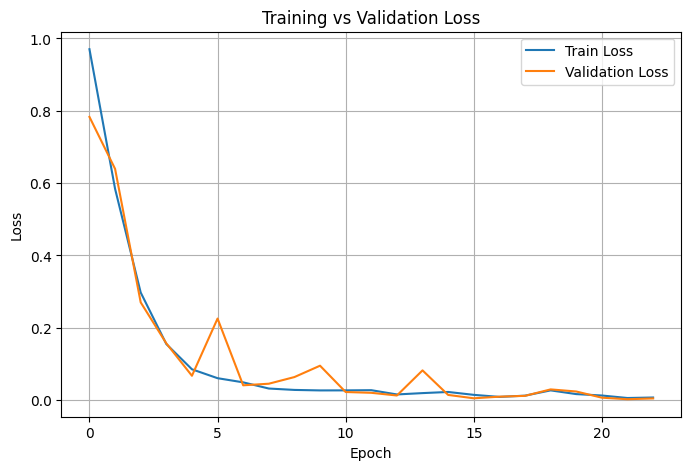

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

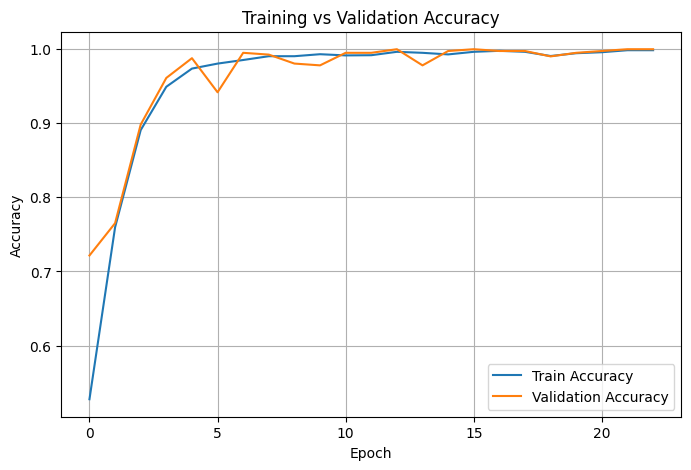

In [23]:
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

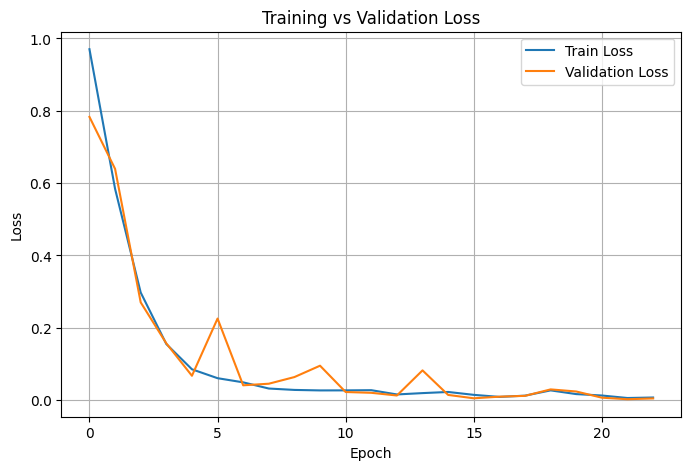

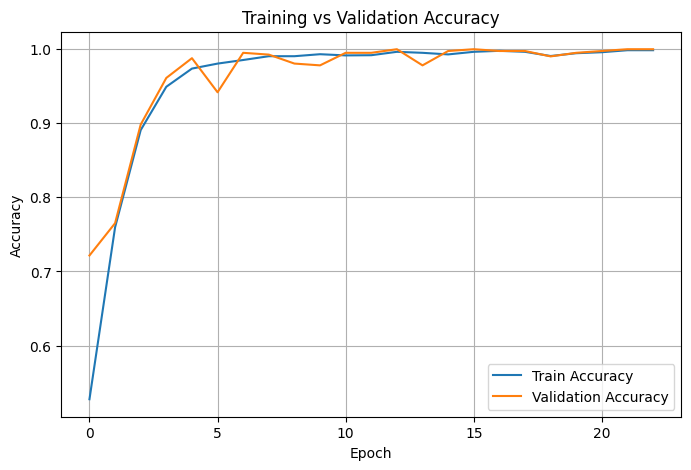

In [24]:
# Save Loss Curve
plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "loss_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

# Save Accuracy Curve
plt.figure(figsize=(8, 5))
plt.plot(history["train_acc"], label="Train Accuracy")
plt.plot(history["val_acc"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.savefig(os.path.join(SAVE_DIR, "accuracy_curve.png"), dpi=300, bbox_inches="tight")
plt.show()

**Model Evaluation and Performance Metrics**

* Run test inference and measure testing time
* Overall accuracy
* Per-class accuracy
* Precision, Recall, F1-score
* Full classification report
* Confusion Matrix
* ROC-AUC calculation
* Plot ROC curves

In [25]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    auc
)
from sklearn.preprocessing import label_binarize


model.eval()

all_labels = []
all_preds = []
all_probs = []

start_test_time = time.time()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)

        _, preds = torch.max(outputs, dim=1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

total_test_time = time.time() - start_test_time

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.array(all_probs)

print(f"Total Testing Time: {total_test_time:.2f} seconds")
print("Shapes:")
print("Labels:", all_labels.shape)
print("Predictions:", all_preds.shape)
print("Probabilities:", all_probs.shape)

overall_accuracy = accuracy_score(all_labels, all_preds)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")



Total Testing Time: 6.01 seconds
Shapes:
Labels: (1031,)
Predictions: (1031,)
Probabilities: (1031, 3)
Overall Test Accuracy: 0.9942


Per-class accuracy & Precision, Recall, F1-score

In [26]:
class_names = ["AD", "MCI", "CN"]

cm = confusion_matrix(all_labels, all_preds)

per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

print("\nPer-Class Accuracy:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {per_class_accuracy[i]:.4f}")


precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="macro", zero_division=0
)

precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_labels, all_preds, average="weighted", zero_division=0
)

print("\nMacro Metrics:")
print(f"Precision (Macro): {precision_macro:.4f}")
print(f"Recall (Macro):    {recall_macro:.4f}")
print(f"F1-score (Macro):  {f1_macro:.4f}")

print("\nWeighted Metrics:")
print(f"Precision (Weighted): {precision_weighted:.4f}")
print(f"Recall (Weighted):    {recall_weighted:.4f}")
print(f"F1-score (Weighted):  {f1_weighted:.4f}")





Per-Class Accuracy:
AD: 0.9867
MCI: 1.0000
CN: 0.9896

Macro Metrics:
Precision (Macro): 0.9948
Recall (Macro):    0.9921
F1-score (Macro):  0.9934

Weighted Metrics:
Precision (Weighted): 0.9942
Recall (Weighted):    0.9942
F1-score (Weighted):  0.9942


Full classification report

In [27]:
report = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    digits=4,
    zero_division=0
)

print("\nClassification Report:\n")
print(report)


Classification Report:

              precision    recall  f1-score   support

          AD     0.9955    0.9867    0.9911       225
         MCI     0.9923    1.0000    0.9962       518
          CN     0.9965    0.9896    0.9930       288

    accuracy                         0.9942      1031
   macro avg     0.9948    0.9921    0.9934      1031
weighted avg     0.9942    0.9942    0.9942      1031



Confusion Matrix

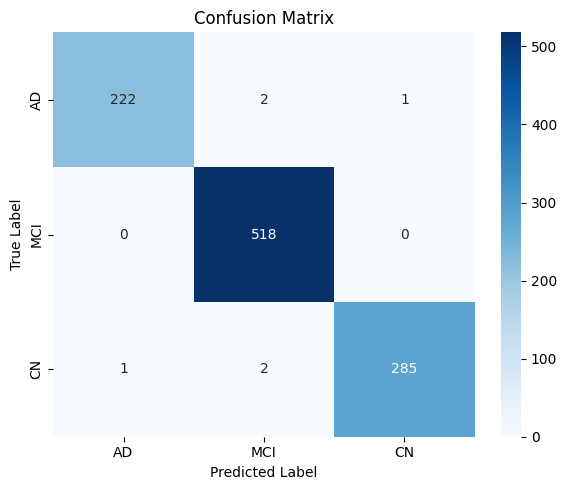

In [28]:
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "confusion_matrix.png"), dpi=300, bbox_inches="tight")
plt.show()

ROC-AUC calculation

In [29]:
# Binarize labels for multiclass ROC-AUC
all_labels_bin = label_binarize(all_labels, classes=[0, 1, 2])

# Per-class ROC-AUC
roc_auc_per_class = {}
fpr = {}
tpr = {}
roc_auc_curves = {}

for i, class_name in enumerate(class_names):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc_curves[i] = auc(fpr[i], tpr[i])
    roc_auc_per_class[class_name] = roc_auc_curves[i]

# Macro-average ROC-AUC
macro_roc_auc = roc_auc_score(
    all_labels_bin,
    all_probs,
    average="macro",
    multi_class="ovr"
)

weighted_roc_auc = roc_auc_score(
    all_labels_bin,
    all_probs,
    average="weighted",
    multi_class="ovr"
)

print("\nPer-Class ROC-AUC:")
for class_name, score in roc_auc_per_class.items():
    print(f"{class_name}: {score:.4f}")

print(f"\nMacro ROC-AUC:    {macro_roc_auc:.4f}")
print(f"Weighted ROC-AUC: {weighted_roc_auc:.4f}")


Per-Class ROC-AUC:
AD: 0.9999
MCI: 1.0000
CN: 1.0000

Macro ROC-AUC:    1.0000
Weighted ROC-AUC: 1.0000


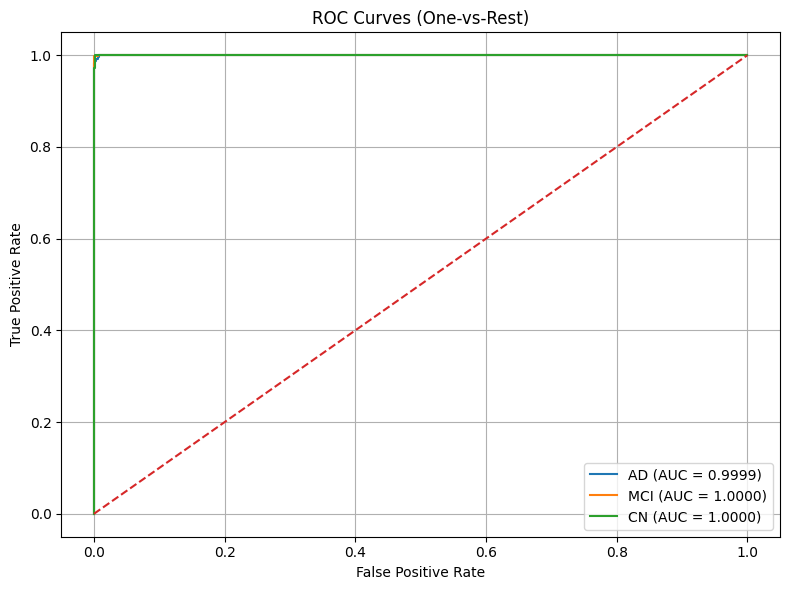

In [30]:
plt.figure(figsize=(8, 6))

for i, class_name in enumerate(class_names):
    plt.plot(fpr[i], tpr[i], label=f"{class_name} (AUC = {roc_auc_curves[i]:.4f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(SAVE_DIR, "roc_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

In [32]:
results_dict = {
    "Model": "MobileNetV2",
    "Input_Size": f"{IMG_SIZE}x{IMG_SIZE}",
    "Overall_Accuracy": overall_accuracy,

    "AD_Accuracy": per_class_accuracy[0],
    "MCI_Accuracy": per_class_accuracy[1],
    "CN_Accuracy": per_class_accuracy[2],

    "Precision_Macro": precision_macro,
    "Recall_Macro": recall_macro,
    "F1_Macro": f1_macro,

    "Precision_Weighted": precision_weighted,
    "Recall_Weighted": recall_weighted,
    "F1_Weighted": f1_weighted,

    "AD_ROC_AUC": roc_auc_per_class["AD"],
    "MCI_ROC_AUC": roc_auc_per_class["MCI"],
    "CN_ROC_AUC": roc_auc_per_class["CN"],

    "Macro_ROC_AUC": macro_roc_auc,
    "Weighted_ROC_AUC": weighted_roc_auc,

    "Training_Time_sec": total_training_time,
    "Testing_Time_sec": total_test_time,
    "Best_Val_Accuracy": best_val_acc,
    "Best_Epoch": best_epoch
}

results_df = pd.DataFrame([results_dict])
results_csv_path = os.path.join(SAVE_DIR, "final_results.csv")
results_df.to_csv(results_csv_path, index=False)

print("Final results saved to:", results_csv_path)
display(results_df)

report_dict = classification_report(
    all_labels,
    all_preds,
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_df = pd.DataFrame(report_dict).transpose()
report_csv_path = os.path.join(SAVE_DIR, "classification_report.csv")
report_df.to_csv(report_csv_path, index=True)

print("Classification report saved to:", report_csv_path)
display(report_df)

Final results saved to: /kaggle/working/mobilenetv2_results/final_results.csv


,Model,Input_Size,Overall_Accuracy,AD_Accuracy,MCI_Accuracy,CN_Accuracy,Precision_Macro,Recall_Macro,F1_Macro,Precision_Weighted,...,F1_Weighted,AD_ROC_AUC,MCI_ROC_AUC,CN_ROC_AUC,Macro_ROC_AUC,Weighted_ROC_AUC,Training_Time_sec,Testing_Time_sec,Best_Val_Accuracy,Best_Epoch
0,MobileNetV2,224x224,0.99418,0.986667,1.0,0.989583,0.994785,0.992083,0.993419,0.994195,...,0.994172,0.999923,0.999989,0.999963,0.999958,0.999967,354.169562,6.005526,1.0,13


Classification report saved to: /kaggle/working/mobilenetv2_results/classification_report.csv


,precision,recall,f1-score,support
AD,0.995516,0.986667,0.991071,225.00000
MCI,0.992337,1.000000,0.996154,518.00000
CN,0.996503,0.989583,0.993031,288.00000
accuracy,0.994180,0.994180,0.994180,0.99418
macro avg,0.994785,0.992083,0.993419,1031.00000
weighted avg,0.994195,0.994180,0.994172,1031.00000


**Computational Complexity, Inference Efficiency, and Failure Mode Analysis**

* GFLOPs
* parameter count
* test time
* average inference time
* report-ready summary table
* failure modes from confusion matrix

install and compute FLOPs & GFLOPs

In [33]:
!pip install -q thop

In [35]:
from thop import profile
from thop import clever_format

# Make a dummy input
dummy_input = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(device)

# Compute FLOPs and parameters
flops, params = profile(model, inputs=(dummy_input,), verbose=False)

# Convert to readable format
flops_readable, params_readable = clever_format([flops, params], "%.3f")

print(f"Input Size: 1 x 3 x {IMG_SIZE} x {IMG_SIZE}")
print(f"FLOPs per inference: {flops_readable}")
print(f"Parameters: {params_readable}")



gflops = flops / 1e9
million_params = params / 1e6

print(f"GFLOPs per inference: {gflops:.4f}")
print(f"Parameters (Millions): {million_params:.4f} M")

Input Size: 1 x 3 x 224 x 224
FLOPs per inference: 326.211M
Parameters: 2.228M
GFLOPs per inference: 0.3262
Parameters (Millions): 2.2277 M


Average inference time per image

In [41]:
num_test_samples = len(test_dataset)
avg_inference_time_per_image = total_test_time / num_test_samples

print(f"Total test samples: {num_test_samples}")
print(f"Average inference time per image: {avg_inference_time_per_image:.6f} seconds")


avg_inference_time_ms = avg_inference_time_per_image * 1000
print(f"Average inference time per image: {avg_inference_time_ms:.4f} ms")

Total test samples: 1031
Average inference time per image: 0.005825 seconds
Average inference time per image: 5.8250 ms


Save compute-cost summary

In [43]:
compute_summary = {
    "Model": "MobileNetV2",
    "Input_Size": f"{IMG_SIZE}x{IMG_SIZE}",
    "GFLOPs_per_Inference": gflops,
    "Parameters_Million": million_params,
    "Total_Test_Time_sec": total_test_time,
    "Avg_Inference_Time_per_Image_ms": avg_inference_time_ms,
    "Total_Training_Time_sec": total_training_time
}

compute_df = pd.DataFrame([compute_summary])

compute_csv_path = os.path.join(SAVE_DIR, "compute_summary.csv")
compute_df.to_csv(compute_csv_path, index=False)

print("Compute summary saved to:", compute_csv_path)
display(compute_df)

Compute summary saved to: /kaggle/working/mobilenetv2_results/compute_summary.csv


,Model,Input_Size,GFLOPs_per_Inference,Parameters_Million,Total_Test_Time_sec,Avg_Inference_Time_per_Image_ms,Total_Training_Time_sec
0,MobileNetV2,224x224,0.326211,2.227715,6.005526,5.824953,354.169562


final report-ready summary table

In [44]:
final_summary_dict = {
    "Model": "MobileNetV2",
    "Train_Test_Split": f"{TRAIN_PERCENT}:{TEST_PERCENT}",
    "Input_Size": f"{IMG_SIZE}x{IMG_SIZE}",

    "Accuracy": overall_accuracy,
    "AD_Acc": per_class_accuracy[0],
    "MCI_Acc": per_class_accuracy[1],
    "CN_Acc": per_class_accuracy[2],

    "Precision_Macro": precision_macro,
    "Recall_Macro": recall_macro,
    "F1_Macro": f1_macro,

    "Macro_ROC_AUC": macro_roc_auc,

    "Training_Time_sec": total_training_time,
    "Testing_Time_sec": total_test_time,
    "Avg_Inference_Time_ms": avg_inference_time_ms,
    "GFLOPs": gflops,
    "Params_M": million_params,
    "Best_Epoch": best_epoch,
    "Best_Val_Acc": best_val_acc
}

final_summary_df = pd.DataFrame([final_summary_dict])

final_summary_path = os.path.join(SAVE_DIR, "report_ready_summary.csv")
final_summary_df.to_csv(final_summary_path, index=False)

print("Report-ready summary saved to:", final_summary_path)
display(final_summary_df)

Report-ready summary saved to: /kaggle/working/mobilenetv2_results/report_ready_summary.csv


,Model,Train_Test_Split,Input_Size,Accuracy,AD_Acc,MCI_Acc,CN_Acc,Precision_Macro,Recall_Macro,F1_Macro,Macro_ROC_AUC,Training_Time_sec,Testing_Time_sec,Avg_Inference_Time_ms,GFLOPs,Params_M,Best_Epoch,Best_Val_Acc
0,MobileNetV2,80:20,224x224,0.99418,0.986667,1.0,0.989583,0.994785,0.992083,0.993419,0.999958,354.169562,6.005526,5.824953,0.326211,2.227715,13,1.0


In [45]:
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
cm_csv_path = os.path.join(SAVE_DIR, "confusion_matrix_values.csv")
cm_df.to_csv(cm_csv_path)

print("Confusion matrix values saved to:", cm_csv_path)
display(cm_df)

Confusion matrix values saved to: /kaggle/working/mobilenetv2_results/confusion_matrix_values.csv


,AD,MCI,CN
AD,222,2,1
MCI,0,518,0
CN,1,2,285


Failure mode summary
and find the biggest confusions

In [46]:
failure_modes = []

for i in range(len(class_names)):
    for j in range(len(class_names)):
        if i != j:
            failure_modes.append({
                "True_Class": class_names[i],
                "Predicted_As": class_names[j],
                "Count": cm[i, j]
            })

failure_modes_df = pd.DataFrame(failure_modes)
failure_modes_df = failure_modes_df.sort_values(by="Count", ascending=False).reset_index(drop=True)

failure_modes_path = os.path.join(SAVE_DIR, "failure_modes.csv")
failure_modes_df.to_csv(failure_modes_path, index=False)

print("Failure modes saved to:", failure_modes_path)
display(failure_modes_df.head(10))

Failure modes saved to: /kaggle/working/mobilenetv2_results/failure_modes.csv


,True_Class,Predicted_As,Count
0,AD,MCI,2
1,CN,MCI,2
2,AD,CN,1
3,CN,AD,1
4,MCI,CN,0
5,MCI,AD,0
